# 📘 Capítulo 2: Límites y Continuidad
### Métodos Cuantitativos para la Economía — MSc. Jeel Cueva

---
> *"El cálculo es el modo más poderoso de manejar la idea de que el infinito puede ser comprendido."*  
> — Richard Courant

**Contenido:** Límites directos, formas indeterminadas, límites laterales, asíntotas, continuidad, TVI.

In [1]:
# IMPORTACIONES
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3,
    'axes.spines.top':False,'axes.spines.right':False})
C_AZUL='#1f77b4'; C_ROJO='#d62728'; C_VERDE='#2ca02c'
C_NARANJA='#ff7f0e'; C_MORADO='#9467bd'
print('Librerías cargadas.')

Librerías cargadas.


## Ejemplo 2.1 — Límites directos por sustitución
### $\lim_{x\to 3}(2x^2-5x+1)$ y $\lim_{x\to 2}\frac{x^3+x}{x^2+1}$

lim(x→3) [2x²-5x+1] = 4
lim(x→2) [(x³+x)/(x²+1)] = 2
lim(x→4) [√(2x+1)] = 3


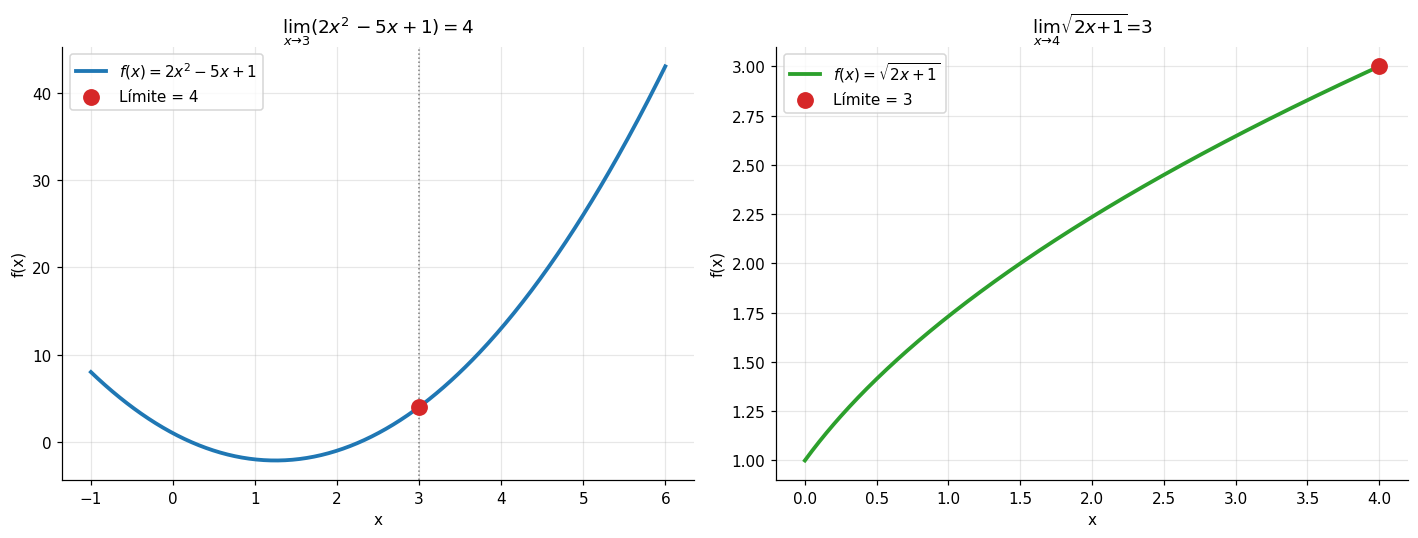

In [2]:
# EJEMPLO 2.1 — Límites por sustitución directa
x = sp.Symbol('x')

# (a) polinomio
f1 = 2*x**2 - 5*x + 1
lim1 = sp.limit(f1, x, 3)
print(f'lim(x→3) [2x²-5x+1] = {lim1}')

# (b) función racional
f2 = (x**3 + x)/(x**2 + 1)
lim2 = sp.limit(f2, x, 2)
print(f'lim(x→2) [(x³+x)/(x²+1)] = {lim2}')

# (c) raíz
f3 = sp.sqrt(2*x + 1)
lim3 = sp.limit(f3, x, 4)
print(f'lim(x→4) [√(2x+1)] = {lim3}')

# Visualización
x_v = np.linspace(-1, 6, 400)
f1_v = 2*x_v**2 - 5*x_v + 1
x_v2 = np.linspace(0, 4, 400)
f3_v = np.sqrt(2*x_v2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(x_v, f1_v, color=C_AZUL, lw=2.5, label='$f(x)=2x^2-5x+1$')
ax.scatter([3], [float(lim1)], color=C_ROJO, s=100, zorder=6, label=f'Límite = {lim1}')
ax.axvline(3, color='gray', ls=':', lw=1)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('$\\lim_{{x\\to 3}}(2x^2-5x+1) = 4$'); ax.legend()

ax2 = axes[1]
ax2.plot(x_v2, f3_v, color=C_VERDE, lw=2.5, label='$f(x)=\\sqrt{2x+1}$')
ax2.scatter([4], [float(lim3)], color=C_ROJO, s=100, zorder=6, label=f'Límite = {lim3}')
ax2.set_xlabel('x'); ax2.set_ylabel('f(x)')
ax2.set_title('$\\lim_{{x\\to 4}}\\sqrt{{2x+1}} = 3$'); ax2.legend()
plt.tight_layout(); plt.savefig('fig_c02_limites_directos.png', bbox_inches='tight')
plt.show()

## Ejemplo 2.2 — Formas Indeterminadas $0/0$
### Factorización, racionalización y regla de L'Hôpital

(a) lim(x→3) (x²-9)/(x-3) = 6
    (x²-9)=(x-3)(x+3) → cancela → lim(x+3) = 6
(b) lim(x→4) (√x-2)/(x-4) = 1/4
(c) lim(x→1) (x³-1)/(x-1) = 3
(d) lim(x→0) (3x²+2x)/x = 2


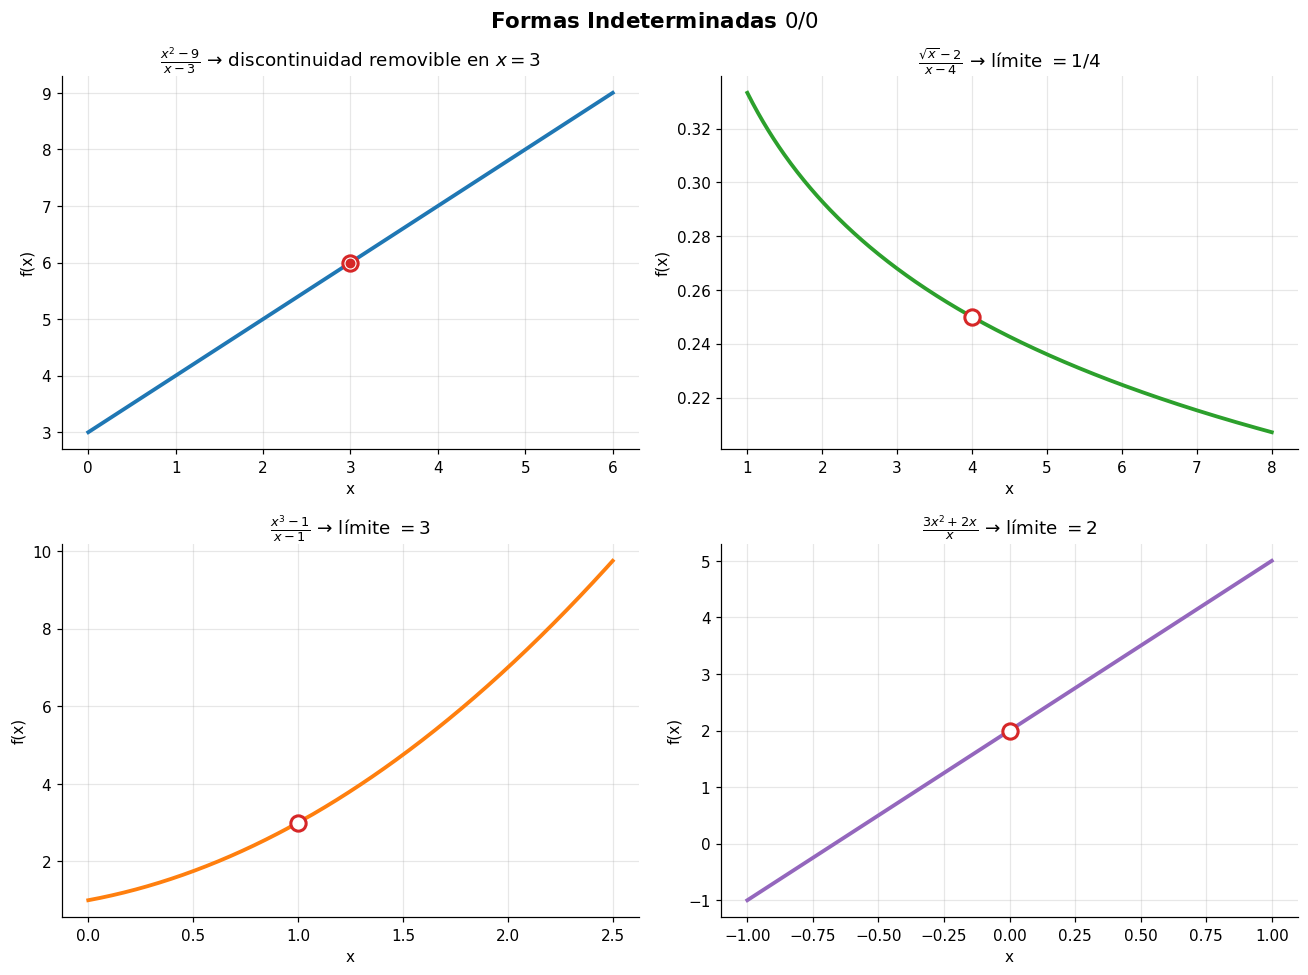

In [3]:
# EJEMPLO 2.2 — Formas indeterminadas 0/0
x = sp.Symbol('x')

# (a) Factorización: lim (x²-9)/(x-3)
f_a = (x**2 - 9)/(x - 3)
lim_a = sp.limit(f_a, x, 3)
print(f'(a) lim(x→3) (x²-9)/(x-3) = {lim_a}')
print(f'    (x²-9)=(x-3)(x+3) → cancela → lim(x+3) = 6')

# (b) Racionalización: lim (√x-2)/(x-4)
f_b = (sp.sqrt(x) - 2)/(x - 4)
lim_b = sp.limit(f_b, x, 4)
print(f'(b) lim(x→4) (√x-2)/(x-4) = {lim_b}')

# (c) Diferencia de cubos: lim (x³-1)/(x-1)
f_c = (x**3 - 1)/(x - 1)
lim_c = sp.limit(f_c, x, 1)
print(f'(c) lim(x→1) (x³-1)/(x-1) = {lim_c}')

# (d) Límite con factor común: lim (3x²+2x)/x
f_d = (3*x**2 + 2*x)/x
lim_d = sp.limit(f_d, x, 0)
print(f'(d) lim(x→0) (3x²+2x)/x = {lim_d}')

# Gráficas
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a)
x_v = np.linspace(0, 6, 400)
mask = np.abs(x_v - 3) > 0.05
x_a = x_v[mask]; f_av = (x_a**2-9)/(x_a-3)
axes[0,0].plot(x_a, f_av, color=C_AZUL, lw=2.5)
axes[0,0].scatter([3],[6], color='white', edgecolors=C_ROJO, s=100, zorder=6, linewidths=2)
axes[0,0].scatter([3],[6], color=C_ROJO, s=30, zorder=7)
axes[0,0].set_title('$\\frac{x^2-9}{x-3}$ → discontinuidad removible en $x=3$')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('f(x)')

# (b)
x_v2 = np.linspace(1, 8, 400)
mask2 = np.abs(x_v2-4) > 0.05
x_b = x_v2[mask2]; f_bv = (np.sqrt(x_b)-2)/(x_b-4)
axes[0,1].plot(x_b, f_bv, color=C_VERDE, lw=2.5)
axes[0,1].scatter([4],[0.25],color='white',edgecolors=C_ROJO,s=100,zorder=6,linewidths=2)
axes[0,1].set_title('$\\frac{\\sqrt{x}-2}{x-4}$ → límite $= 1/4$')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('f(x)')

# (c)
x_v3 = np.linspace(0, 2.5, 400)
mask3 = np.abs(x_v3-1) > 0.05
x_c = x_v3[mask3]; f_cv = (x_c**3-1)/(x_c-1)
axes[1,0].plot(x_c, f_cv, color=C_NARANJA, lw=2.5)
axes[1,0].scatter([1],[3],color='white',edgecolors=C_ROJO,s=100,zorder=6,linewidths=2)
axes[1,0].set_title('$\\frac{x^3-1}{x-1}$ → límite $= 3$')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('f(x)')

# (d)
x_v4 = np.linspace(-1, 1, 400)
mask4 = np.abs(x_v4) > 0.05
x_d = x_v4[mask4]; f_dv = (3*x_d**2+2*x_d)/x_d
axes[1,1].plot(x_d, f_dv, color=C_MORADO, lw=2.5)
axes[1,1].scatter([0],[2],color='white',edgecolors=C_ROJO,s=100,zorder=6,linewidths=2)
axes[1,1].set_title('$\\frac{3x^2+2x}{x}$ → límite $= 2$')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('f(x)')

plt.suptitle('Formas Indeterminadas $0/0$', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_c02_indeterminadas.png', bbox_inches='tight')
plt.show()

## Ejemplo 2.3 — Límites Laterales y Discontinuidades
### Función por tramos, función valor absoluto, estructura de precios

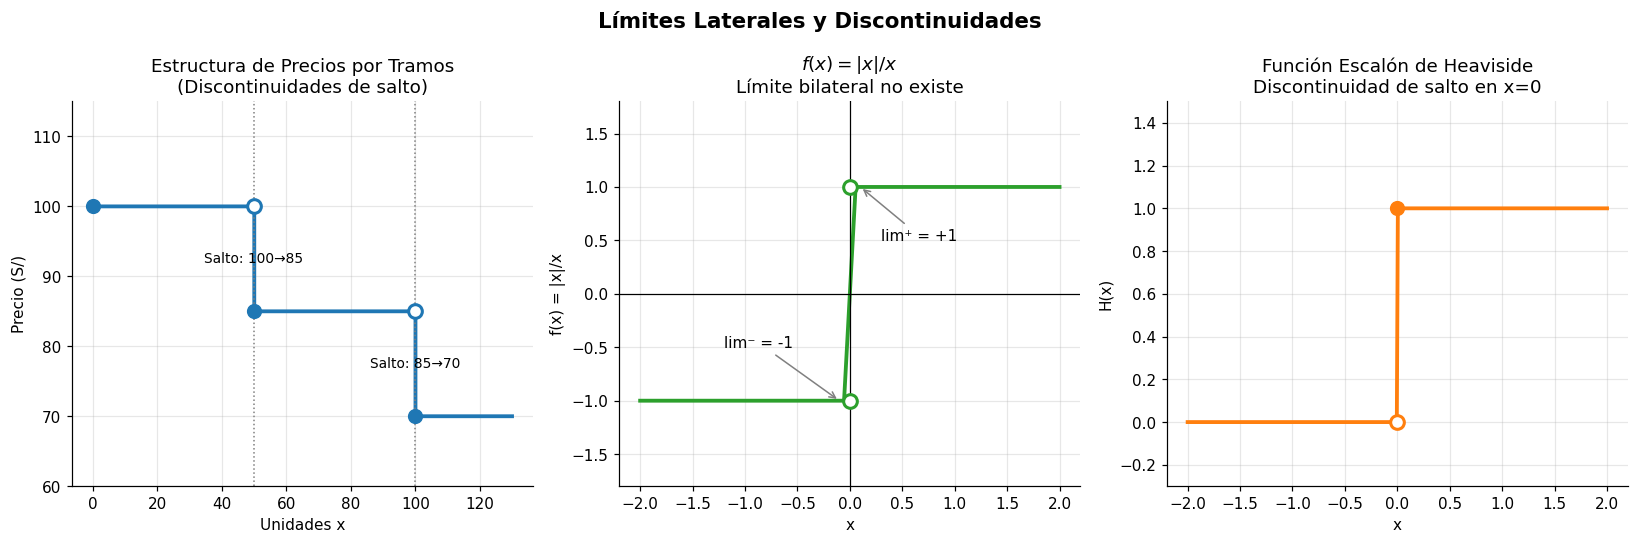

In [4]:
# EJEMPLO 2.3 — Límites laterales y discontinuidades
x = sp.Symbol('x')

# Función precios por tramos (empresa manufacturera del libro)
# P(x) = 100 si 0<=x<50, 85 si 50<=x<100, 70 si x>=100
def P_precio(x_v):
    return np.where(x_v < 50, 100, np.where(x_v < 100, 85, 70))

# Función valor absoluto: |x|/x
x_abs = np.linspace(-2, 2, 400)
mask_abs = np.abs(x_abs) > 0.05
x_abs_f = x_abs[mask_abs]
f_abs = np.sign(x_abs_f)  # = |x|/x

# Función de Heaviside
x_h = np.linspace(-2, 2, 400)
H = np.where(x_h >= 0, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Precios por tramos
ax = axes[0]
x_p = np.linspace(0, 130, 1000)
P_v = P_precio(x_p)
ax.step(x_p, P_v, color=C_AZUL, lw=2.5, where='post', label='P(x)')
# Puntos llenos y vacíos
ax.scatter([0,50,100],[100,85,70],color=C_AZUL,s=80,zorder=6)
ax.scatter([50,100],[100,85],color='white',edgecolors=C_AZUL,s=80,zorder=7,linewidths=2)
ax.axvline(50,color='gray',ls=':',lw=1); ax.axvline(100,color='gray',ls=':',lw=1)
ax.annotate('Salto: 100→85',xy=(50,92),fontsize=9,ha='center')
ax.annotate('Salto: 85→70',xy=(100,77),fontsize=9,ha='center')
ax.set_xlabel('Unidades x'); ax.set_ylabel('Precio (S/)')
ax.set_title('Estructura de Precios por Tramos\n(Discontinuidades de salto)')
ax.set_ylim(60,115)

# Panel 2: |x|/x
ax2 = axes[1]
ax2.plot(x_abs_f, f_abs, color=C_VERDE, lw=2.5)
ax2.scatter([0],[1],color='white',edgecolors=C_VERDE,s=80,zorder=6,linewidths=2)
ax2.scatter([0],[-1],color='white',edgecolors=C_VERDE,s=80,zorder=6,linewidths=2)
ax2.axhline(0,color='black',lw=0.8)
ax2.axvline(0,color='black',lw=0.8)
ax2.annotate('lim⁻ = -1',xy=(-0.1,-1),xytext=(-1.2,-0.5),fontsize=10,
    arrowprops=dict(arrowstyle='->',color='gray'))
ax2.annotate('lim⁺ = +1',xy=(0.1,1),xytext=(0.3,0.5),fontsize=10,
    arrowprops=dict(arrowstyle='->',color='gray'))
ax2.set_xlabel('x'); ax2.set_ylabel('f(x) = |x|/x')
ax2.set_title('$f(x)=|x|/x$\nLímite bilateral no existe')
ax2.set_ylim(-1.8,1.8)

# Panel 3: Heaviside
ax3 = axes[2]
ax3.plot(x_h, H, color=C_NARANJA, lw=2.5, label='H(x)')
ax3.scatter([0],[1],color=C_NARANJA,s=80,zorder=6)
ax3.scatter([0],[0],color='white',edgecolors=C_NARANJA,s=80,zorder=7,linewidths=2)
ax3.set_xlabel('x'); ax3.set_ylabel('H(x)')
ax3.set_title('Función Escalón de Heaviside\nDiscontinuidad de salto en x=0')
ax3.set_ylim(-0.3,1.5)

plt.suptitle('Límites Laterales y Discontinuidades', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_c02_laterales.png', bbox_inches='tight')
plt.show()

## Ejemplo 2.4 — Límites al Infinito y Asíntotas Horizontales
### Saturación de mercado y costo medio a largo plazo

Saturación tecnológica: lim(t→∞) = 85%
lim(x→∞) (3x²+2x+1)/(5x²-4x+7) = 3/5
Costo medio: mínimo en x=316.2 → Costo medio mín=6.265


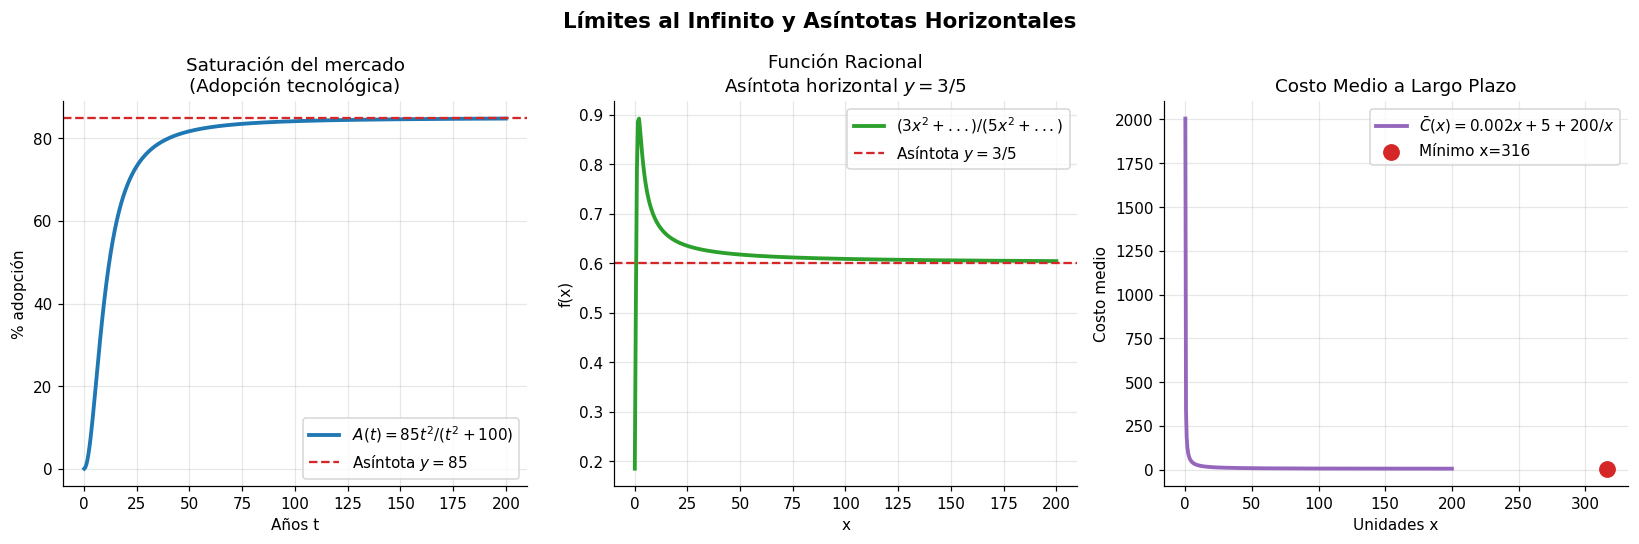

In [5]:
# EJEMPLO 2.4 — Límites al infinito y asíntotas
x = sp.Symbol('x', positive=True)

# (a) Modelo de adopción tecnológica
A = 85*x**2/(x**2 + 100)
lim_A = sp.limit(A, x, sp.oo)
print(f'Saturación tecnológica: lim(t→∞) = {lim_A}%')

# (b) Función racional grado=grado
f_r = (3*x**2 + 2*x + 1)/(5*x**2 - 4*x + 7)
lim_r = sp.limit(f_r, x, sp.oo)
print(f'lim(x→∞) (3x²+2x+1)/(5x²-4x+7) = {lim_r}')

# (c) Costo medio C(x)=0.002x²+5x+200
C_tot = 0.002*x**2 + 5*x + 200
C_med = C_tot/x
C_med_min_x = sp.solve(sp.diff(C_med, x), x)[0]
C_med_min   = float(C_med.subs(x, C_med_min_x))
print(f'Costo medio: mínimo en x={float(C_med_min_x):.1f} → Costo medio mín={C_med_min:.3f}')

t_vals = np.linspace(0.1, 200, 400)
A_vals = 85*t_vals**2 / (t_vals**2 + 100)
f_r_v = (3*t_vals**2+2*t_vals+1)/(5*t_vals**2-4*t_vals+7)
C_med_v = 0.002*t_vals + 5 + 200/t_vals

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax=axes[0]
ax.plot(t_vals, A_vals, color=C_AZUL, lw=2.5, label='$A(t)=85t^2/(t^2+100)$')
ax.axhline(85, color=C_ROJO, ls='--', lw=1.5, label='Asíntota $y=85$')
ax.set_xlabel('Años t'); ax.set_ylabel('% adopción')
ax.set_title('Saturación del mercado\n(Adopción tecnológica)'); ax.legend()

ax2=axes[1]
ax2.plot(t_vals, f_r_v, color=C_VERDE, lw=2.5, label='$(3x^2+...)/(5x^2+...)$')
ax2.axhline(3/5, color=C_ROJO, ls='--', lw=1.5, label='Asíntota $y=3/5$')
ax2.set_xlabel('x'); ax2.set_ylabel('f(x)')
ax2.set_title('Función Racional\nAsíntota horizontal $y=3/5$'); ax2.legend()

ax3=axes[2]
ax3.plot(t_vals, C_med_v, color=C_MORADO, lw=2.5, label='$\\bar{C}(x)=0.002x+5+200/x$')
xmin = float(C_med_min_x)
ax3.scatter([xmin],[C_med_min],color=C_ROJO,s=100,zorder=6,label=f'Mínimo x={xmin:.0f}')
ax3.set_xlabel('Unidades x'); ax3.set_ylabel('Costo medio')
ax3.set_title('Costo Medio a Largo Plazo'); ax3.legend()

plt.suptitle('Límites al Infinito y Asíntotas Horizontales', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_c02_asintota_horiz.png', bbox_inches='tight')
plt.show()

## Ejemplo 2.5 — Continuidad y Teorema del Valor Intermedio (TVI)
### Garantía de equilibrio de mercado con funciones no lineales

EXCESO DE DEMANDA: E(p) = 600 - 3p² - 2p
  E(5)  = 515.0  > 0 (exceso de demanda)
  E(15) = -105.0 < 0 (exceso de oferta)
  TVI garantiza ∃ p* ∈ (5,15) con E(p*)=0
  p* exacto ≈ -14.4794
  Bisección: E(10)=280.0, E(13)=67.0, E(14)=-16.0 → p*∈(13,14)


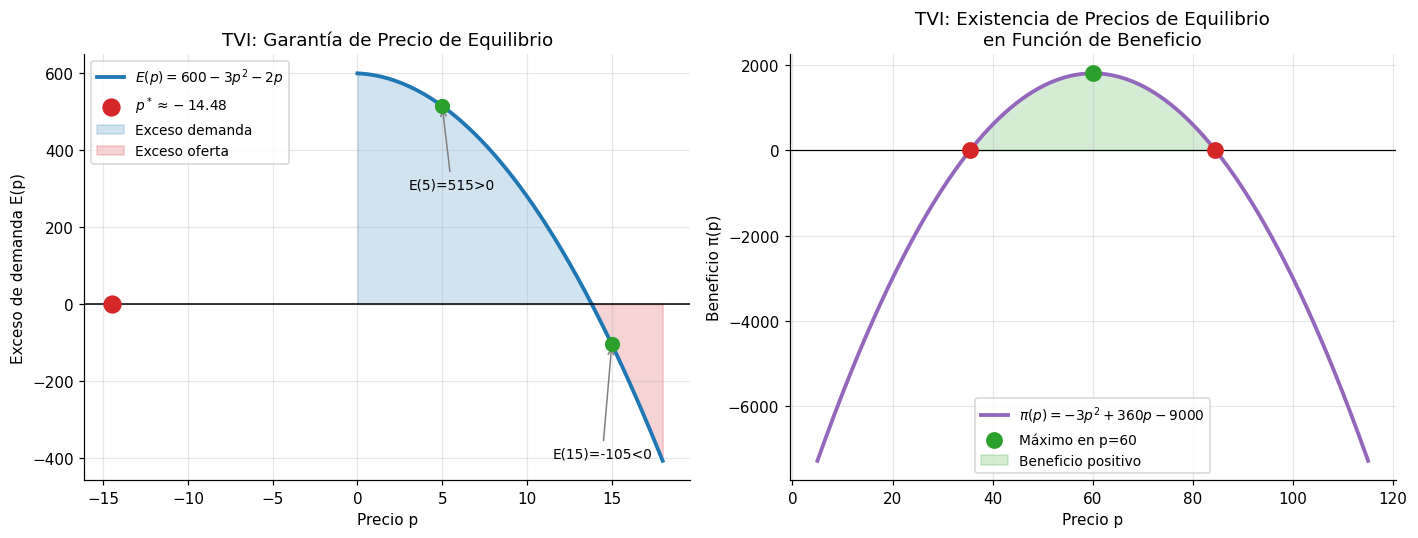

In [6]:
# EJEMPLO 2.5 — TVI aplicado al equilibrio de mercado
# Exceso de demanda: E(p) = 600 - 3p² - 2p
p = sp.Symbol('p')
E = 600 - 3*p**2 - 2*p
E5  = float(E.subs(p, 5))
E15 = float(E.subs(p, 15))
p_eq_num = float(sp.solve(E, p)[1])  # raíz positiva
print('EXCESO DE DEMANDA: E(p) = 600 - 3p² - 2p')
print(f'  E(5)  = {E5:.1f}  > 0 (exceso de demanda)')
print(f'  E(15) = {E15:.1f} < 0 (exceso de oferta)')
print(f'  TVI garantiza ∃ p* ∈ (5,15) con E(p*)=0')
print(f'  p* exacto ≈ {p_eq_num:.4f}')

# Bisección manual
E10 = float(E.subs(p,10)); E13 = float(E.subs(p,13)); E14 = float(E.subs(p,14))
print(f'  Bisección: E(10)={E10:.1f}, E(13)={E13:.1f}, E(14)={E14:.1f} → p*∈(13,14)')

p_vals = np.linspace(0, 18, 400)
E_vals = 600 - 3*p_vals**2 - 2*p_vals

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(p_vals, E_vals, color=C_AZUL, lw=2.5, label='$E(p)=600-3p^2-2p$')
ax.axhline(0, color='black', lw=1)
ax.scatter([p_eq_num],[0],color=C_ROJO,s=120,zorder=6,label=f'$p^*\\approx{p_eq_num:.2f}$')
ax.scatter([5,15],[E5,E15],color=C_VERDE,s=80,zorder=5)
ax.annotate(f'E(5)={E5:.0f}>0', xy=(5,E5), xytext=(3,300), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f'E(15)={E15:.0f}<0', xy=(15,E15), xytext=(11.5,-400), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray'))
ax.fill_between(p_vals, E_vals, 0, where=(E_vals>0), alpha=0.2, color=C_AZUL, label='Exceso demanda')
ax.fill_between(p_vals, E_vals, 0, where=(E_vals<0), alpha=0.2, color=C_ROJO, label='Exceso oferta')
ax.set_xlabel('Precio p'); ax.set_ylabel('Exceso de demanda E(p)')
ax.set_title('TVI: Garantía de Precio de Equilibrio'); ax.legend(fontsize=9)

# Panel 2: función de beneficio con TVI
ax2 = axes[1]
p2 = np.linspace(5, 115, 400)
pi_v = -3*p2**2 + 360*p2 - 9000
ax2.plot(p2, pi_v, color=C_MORADO, lw=2.5, label='$\\pi(p)=-3p^2+360p-9000$')
ax2.axhline(0, color='black', lw=0.8)
raices_pi = [35.505, 84.495]
for r in raices_pi:
    ax2.scatter([r],[0],color=C_ROJO,s=100,zorder=6)
ax2.scatter([60],[float(-3*60**2+360*60-9000)],color=C_VERDE,s=100,zorder=6,label='Máximo en p=60')
ax2.fill_between(p2, pi_v, 0, where=(pi_v>0), alpha=0.2, color=C_VERDE, label='Beneficio positivo')
ax2.set_xlabel('Precio p'); ax2.set_ylabel('Beneficio π(p)')
ax2.set_title('TVI: Existencia de Precios de Equilibrio\nen Función de Beneficio'); ax2.legend(fontsize=9)

plt.tight_layout(); plt.savefig('fig_c02_TVI.png', bbox_inches='tight')
plt.show()

## Ejemplo 2.6 — Límites Notables
### $\lim_{n\to\infty}(1+r/n)^n = e^r$ — Capitalización continua

CONVERGENCIA A e^r con r=0.06
         n       (1+r/n)^n          e^r
----------------------------------------
         1      1.06000000   1.06183655
         2      1.06090000   1.06183655
         4      1.06136355   1.06183655
        12      1.06167781   1.06183655
        52      1.06179982   1.06183655
       365      1.06183131   1.06183655
      1000      1.06183464   1.06183655
     10000      1.06183636   1.06183655


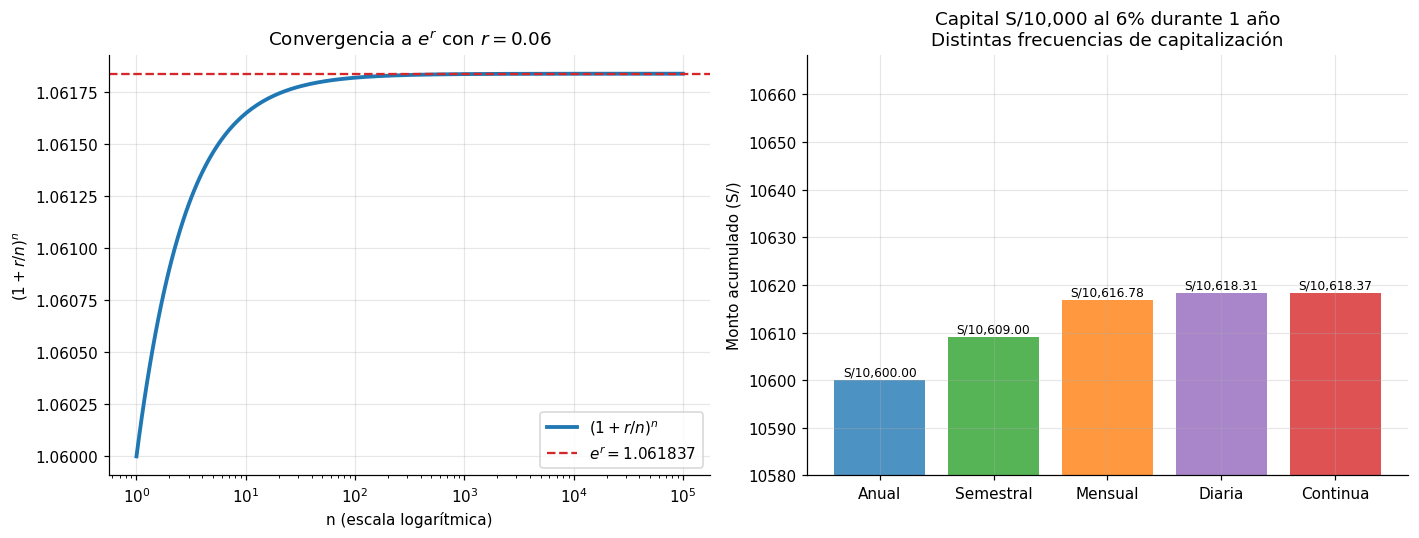

In [7]:
# EJEMPLO 2.6 — Límites notables: número e y capitalización continua
import math

r = 0.06  # tasa anual 6%
A0 = 10000

print('CONVERGENCIA A e^r con r=0.06')
print(f'{"n":>10} {"(1+r/n)^n":>15} {"e^r":>12}')
print('-'*40)
for n in [1, 2, 4, 12, 52, 365, 1000, 10000]:
    val = (1 + r/n)**n
    print(f'{n:>10} {val:>15.8f} {math.exp(r):>12.8f}')

ns = np.logspace(0, 5, 200)
conv = (1 + r/ns)**ns
er = np.exp(r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.semilogx(ns, conv, color=C_AZUL, lw=2.5, label='$(1+r/n)^n$')
ax.axhline(er, color=C_ROJO, ls='--', lw=1.5, label=f'$e^r={er:.6f}$')
ax.set_xlabel('n (escala logarítmica)'); ax.set_ylabel('$(1+r/n)^n$')
ax.set_title(f'Convergencia a $e^r$ con $r={r}$'); ax.legend()

# Tabla de capitalización
periodos = {'Anual':1,'Semestral':2,'Mensual':12,'Diaria':365,'Continua':np.inf}
montos = []
nombres = []
for nom, n_v in periodos.items():
    if np.isinf(n_v):
        m = A0*np.exp(r)
    else:
        m = A0*(1+r/n_v)**n_v
    montos.append(m)
    nombres.append(nom)

ax2 = axes[1]
bars = ax2.bar(nombres, montos, color=[C_AZUL,C_VERDE,C_NARANJA,C_MORADO,C_ROJO], alpha=0.8)
for bar, m in zip(bars, montos):
    ax2.text(bar.get_x()+bar.get_width()/2, m+0.3, f'S/{m:,.2f}', ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Monto acumulado (S/)')
ax2.set_title(f'Capital S/{A0:,.0f} al {r*100:.0f}% durante 1 año\nDistintas frecuencias de capitalización')
ax2.set_ylim(min(montos)-20, max(montos)+50)

plt.tight_layout(); plt.savefig('fig_c02_limite_e.png', bbox_inches='tight')
plt.show()

---
## Resumen del Capítulo 2

| Concepto | Condición | Resultado |
|---|---|---|
| Límite bilateral | $\\lim^- = \\lim^+$ | El límite existe |
| Forma $0/0$ | Factorizar/Racionalizar | Cancelar factor común |
| Forma $\\infty/\\infty$ | Dividir por mayor potencia | Cociente de coeficientes |
| Continuidad | 3 condiciones simultáneas | No hay saltos ni agujeros |
| TVI | $f(a)$ y $f(b)$ tienen signos opuestos | Existe raíz en $(a,b)$ |
| Asíntota horizontal | $\\lim_{x\\to\\infty}f(x)=L$ | Saturaración del modelo |

---
*MSc. Jeel Cueva — UNHEVAL | UDH | UTP — Lima, 2025*